In [1]:
import glob
import PIL.Image as Image
import numpy as np
import pandas as pd

In [2]:
train_paths = glob.glob("train/train_images/*")
train_csv = pd.read_csv("train/train.csv")

In [3]:
train_csv

,id,board_stacks,v_key,label
0,0,"((12, 6, 3, 6), (13, 8, 11, 7), (4, 1, 8, 7), ...",13,1
1,1,"((4, 3, 10, 13), (7, 3, 7, 10), (13, 2, 3, 9),...",1,0
2,2,"((14, 11, 6, 7), (3, 12, 2, 9), (11, 2, 14, 2)...",26,1
3,3,"((2, 2, 6, 2), (10, 6, 1, 1), (10, 8, 14, 8), ...",19,0
4,4,"((2, 6, 8, 13), (6, 8, 9, 3), (13, 12, 12, 4),...",22,2
...,...,...,...,...
795,795,"((8, 13, 1, 11), (4, 3, 3, 10), (1, 14, 5, 10)...",3,1
796,796,"((6, 3, 11, 11), (11, 8, 11, 2), (9, 8, 1, 11)...",20,1
797,797,"((2, 9, 3, 7), (11, 1, 12, 1), (5, 12, 9, 5), ...",27,0
798,798,"((5, 1, 3, 7), (13, 12, 1, 14), (10, 5, 4, 7),...",6,0


In [58]:
from sklearn.decomposition import PCA

data = [eval(x) for x in train_csv["board_stacks"].values]

In [63]:
data = np.array(data)
data = data.reshape(800, -1)

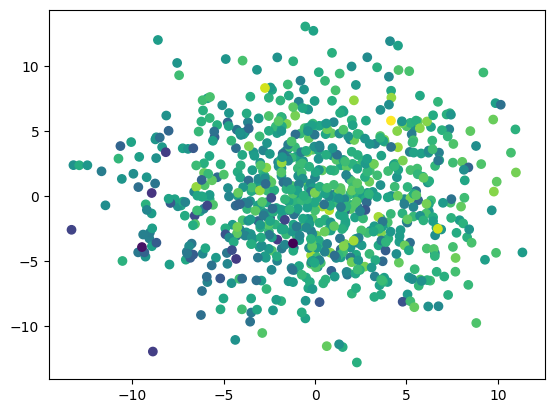

In [68]:
points = PCA(2).fit_transform(data)
plt.scatter(points[:, 0], points[:, 1], c=train_csv["v_key"])

In [70]:
!pip install catboost

     |████████████████████████████████| 28.9 MB 16.9 MB/s eta 0:00:01
     |████████████████████████████████| 47 kB 6.0 MB/s eta 0:00:01
     |████████████████████████████████| 9.9 MB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 451 kB 13.9 MB/s eta 0:00:01
You should consider upgrading via the '/Users/tudormorariu/Documents/ai_work/.venv3.9.6/bin/python3 -m pip install --upgrade pip' command.


In [72]:
import catboost 

model = catboost.CatBoostClassifier().fit(data, train_csv["v_key"])

Learning rate set to 0.078231
0:	learn: 4.2880853	total: 66.6ms	remaining: 1m 6s
1:	learn: 4.2568497	total: 73.5ms	remaining: 36.7s
2:	learn: 4.2288395	total: 80.1ms	remaining: 26.6s
3:	learn: 4.1982727	total: 87.2ms	remaining: 21.7s
4:	learn: 4.1672662	total: 94ms	remaining: 18.7s
5:	learn: 4.1366842	total: 100ms	remaining: 16.6s
6:	learn: 4.1035777	total: 106ms	remaining: 15.1s
7:	learn: 4.0749017	total: 112ms	remaining: 13.9s
8:	learn: 4.0461464	total: 118ms	remaining: 13s
9:	learn: 4.0180134	total: 125ms	remaining: 12.3s
10:	learn: 3.9899943	total: 130ms	remaining: 11.7s
11:	learn: 3.9614197	total: 136ms	remaining: 11.2s
12:	learn: 3.9353475	total: 142ms	remaining: 10.8s
13:	learn: 3.9083883	total: 148ms	remaining: 10.4s
14:	learn: 3.8824866	total: 154ms	remaining: 10.1s
15:	learn: 3.8560728	total: 159ms	remaining: 9.8s
16:	learn: 3.8290704	total: 165ms	remaining: 9.55s
17:	learn: 3.8037334	total: 171ms	remaining: 9.33s
18:	learn: 3.7771853	total: 177ms	remaining: 9.14s
19:	learn: 

In [4]:
import matplotlib.pyplot as plt
import tqdm

train_X = []
train_y = []
imgs_real = []

for i, r in tqdm.tqdm(train_csv.iterrows()):
    path = "train/train_images/" + str(r["id"]) + ".png"
    im = np.array(Image.open(path))
    label = r["label"]
    gens = []
    imgs_real.append(im)
    
    for v in range(0, 15, 1):
        new_im = im.copy()
        new_im[:, :, 0] = ((new_im[:, :, 0].astype(int) - 17 * v) % 256)
        new_im[:, :, 1] = ((new_im[:, :, 1].astype(int) - 17 * v) % 256)
        new_im[:, :, 2] = ((new_im[:, :, 2].astype(int) - 17 * v) % 256)
        # gens.append(new_im)

        train_X.append(new_im)
        train_y.append(label)

800it [00:06, 132.24it/s]


In [12]:
img_real_mean = np.mean(imgs_real, axis=0)

In [13]:
len(imgs_real)

800

In [14]:
img_real_mean.shape

(220, 220, 3)

In [47]:
imgs_real = np.array(imgs_real)

In [56]:
from sklearn.metrics.pairwise import cosine_similarity
import tqdm
sb1 = []

test_paths = glob.glob("test/test_images/*")

for im_path in tqdm.tqdm(test_paths):
    im = np.array(Image.open(im_path))
    v_mses = []
    low = -15


    for v in range(low, 15, 1):
        new_im = im.copy()
        new_im[:, :, 0] = ((new_im[:, :, 0].astype(int) - 17 * v) % 256)
        new_im[:, :, 1] = ((new_im[:, :, 1].astype(int) - 17 * v) % 256)
        new_im[:, :, 2] = ((new_im[:, :, 2].astype(int) - 17 * v) % 256)
        sims = cosine_similarity(new_im.reshape(1, -1), imgs_real.reshape(800, -1))
        v_mses.append(sims[0].argmax())

    min_pos = np.argmin(v_mses)
    v_corr = min_pos - abs(low)
    sb1.append(v_corr)

100%|██████████| 200/200 [22:27<00:00,  6.74s/it]


In [57]:
sb1

[np.int64(-7),
 np.int64(-13),
 np.int64(-2),
 np.int64(-7),
 np.int64(-10),
 np.int64(-5),
 np.int64(-5),
 np.int64(-4),
 np.int64(-12),
 np.int64(5),
 np.int64(-3),
 np.int64(-7),
 np.int64(-14),
 np.int64(-14),
 np.int64(-11),
 np.int64(-7),
 np.int64(-15),
 np.int64(-11),
 np.int64(-15),
 np.int64(-13),
 np.int64(-4),
 np.int64(-3),
 np.int64(-6),
 np.int64(-3),
 np.int64(-2),
 np.int64(-15),
 np.int64(-6),
 np.int64(-8),
 np.int64(-6),
 np.int64(-2),
 np.int64(-6),
 np.int64(-2),
 np.int64(-2),
 np.int64(-12),
 np.int64(-9),
 np.int64(-12),
 np.int64(-12),
 np.int64(-8),
 np.int64(-11),
 np.int64(-4),
 np.int64(-15),
 np.int64(-10),
 np.int64(-5),
 np.int64(-1),
 np.int64(-12),
 np.int64(8),
 np.int64(-11),
 np.int64(-4),
 np.int64(-8),
 np.int64(-9),
 np.int64(-9),
 np.int64(-11),
 np.int64(-15),
 np.int64(-9),
 np.int64(-14),
 np.int64(-6),
 np.int64(-13),
 np.int64(-8),
 np.int64(-10),
 np.int64(-12),
 np.int64(-5),
 np.int64(6),
 np.int64(-12),
 np.int64(-4),
 np.int64(-9),
 n

In [53]:
train_X = np.array(train_X)
train_y = np.array(train_y)

In [21]:
train_X.shape

(12000, 220, 220, 3)

In [22]:
from transformers import ViTImageProcessor

model_name_or_path = 'vit-base-patch16-224-in21k-3class'
processor = ViTImageProcessor.from_pretrained(model_name_or_path)

/Users/tudormorariu/Documents/ai_work/.venv3.9.6/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [23]:
processed_imgs = processor(images=list(train_X), return_tensors="pt")["pixel_values"]

In [24]:
import torch
import torch.nn as nn
import torchvision.models as models

device = "mps"

train_X_tens = torch.Tensor(processed_imgs)
train_y_tens = torch.LongTensor(train_y)

In [25]:

class SkibidiNet(nn.Module):
    def __init__(self):
        super(SkibidiNet, self).__init__()

        self.model_base = models.resnet18(weights=None)
        self.model_base.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 3),
        )
    def forward(self, x):
        x1 = self.model_base(x)
        return self.head(x1)


In [26]:
from transformers import ViTForImageClassification

model = SkibidiNet().to(device)

In [27]:
opt = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
batch_size = 16

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


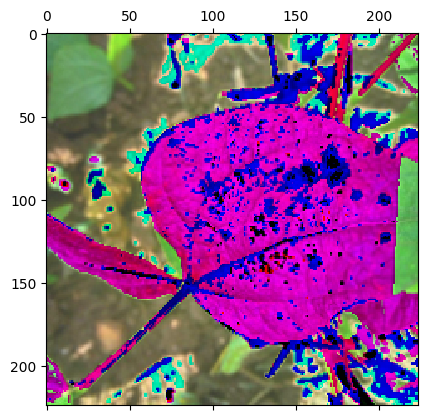

In [28]:
plt.matshow(train_X_tens[6].permute(1, 2, 0))

In [30]:
def train_e(e):
    print("epoch: ", e)
    loss_run = 0
    for i in tqdm.tqdm(range(0, len(train_X_tens), batch_size)):
        X = train_X_tens[i:i + batch_size].to(device)
        y = train_y_tens[i:i + batch_size].to(device)
        
        output = model(X)
        loss = loss_fn(output, y)
        loss_run += loss.item()

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Loss: ", loss_run)

In [ ]:
# train_e(0)

epoch:  0


100%|██████████| 750/750 [01:20<00:00,  9.29it/s]

Loss:  830.9912741780281


In [31]:
model = torch.load("model.pth", weights_only=False)

In [55]:
# for i in range(100): train_e(i)

In [32]:
test_imgs = glob.glob("test/test_images/*")

In [33]:
test_imgs

['test/test_images/837.png',
 'test/test_images/823.png',
 'test/test_images/980.png',
 'test/test_images/994.png',
 'test/test_images/943.png',
 'test/test_images/957.png',
 'test/test_images/956.png',
 'test/test_images/942.png',
 'test/test_images/995.png',
 'test/test_images/981.png',
 'test/test_images/822.png',
 'test/test_images/836.png',
 'test/test_images/820.png',
 'test/test_images/834.png',
 'test/test_images/808.png',
 'test/test_images/997.png',
 'test/test_images/983.png',
 'test/test_images/954.png',
 'test/test_images/940.png',
 'test/test_images/968.png',
 'test/test_images/969.png',
 'test/test_images/941.png',
 'test/test_images/955.png',
 'test/test_images/982.png',
 'test/test_images/996.png',
 'test/test_images/809.png',
 'test/test_images/835.png',
 'test/test_images/821.png',
 'test/test_images/819.png',
 'test/test_images/825.png',
 'test/test_images/831.png',
 'test/test_images/992.png',
 'test/test_images/986.png',
 'test/test_images/979.png',
 'test/test_im

In [34]:
test_X = []

for path in test_imgs:
    test_im = Image.open(path)
    test_im = np.array(test_im)
    test_X.append(test_im)


In [35]:
test_X_prep = processor(images=list(test_X), return_tensors="pt")["pixel_values"]

In [36]:
test_X_prep.shape

torch.Size([200, 3, 224, 224])

In [37]:
test_X_prep = test_X_prep.to(device)

In [38]:
pred = model(test_X_prep)

In [39]:
pred

tensor([[ 5.8614e+00, -5.7255e+00, -1.1668e+01],
        [-7.9890e+00,  4.0037e+00, -6.9067e+00],
        [-1.1753e+01,  1.4817e+00, -9.1780e-02],
        [-1.7961e+01, -2.6446e+00,  9.4969e+00],
        [-4.7718e+00,  4.1496e-01, -8.6398e+00],
        [-3.2238e+00,  1.9085e+00, -9.0104e+00],
        [-3.6388e+00,  1.3188e+00, -7.5987e+00],
        [-8.6458e+00, -4.2929e-01, -2.9687e+00],
        [ 3.4768e+00, -7.9325e+00, -9.7189e+00],
        [ 1.0079e+00, -1.5465e+00, -1.5371e+01],
        [ 4.2860e+00, -4.9543e+00, -1.5640e+01],
        [ 3.9076e+00, -3.8824e+00, -1.1126e+01],
        [ 3.2650e+00, -1.3724e+00, -1.5173e+01],
        [-2.8132e+01, -3.6071e+00,  1.1944e+01],
        [ 2.9620e+00, -2.0172e+00, -1.2002e+01],
        [-1.1916e+01,  5.0301e+00, -9.2290e+00],
        [-3.1192e+01, -4.8325e+00,  1.5252e+01],
        [-1.0293e+00, -2.0039e-01, -9.5055e+00],
        [-2.9712e-01, -1.9725e+00, -9.5133e+00],
        [-1.6783e+01, -2.8895e+00,  1.0997e+01],
        [-2.1302e+01

In [40]:
pred = pred.detach().cpu().numpy()

In [41]:
pred = np.argmax(pred, axis=1)

In [42]:
pred

array([0, 1, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 0, 1, 2, 1, 0, 2, 2, 2,
       0, 2, 0, 1, 2, 0, 0, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 0, 1, 0, 0,
       2, 1, 0, 0, 1, 1, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 2, 1, 1,
       0, 1, 1, 1, 1, 2, 1, 0, 2, 1, 0, 2, 2, 2, 0, 1, 2, 0, 1, 0, 2, 0,
       1, 2, 1, 1, 1, 1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 1, 0, 2, 1, 2, 1, 0,
       2, 1, 2, 0, 1, 2, 0, 1, 1, 2, 1, 0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 0,
       1, 2, 0, 1, 1, 1, 0, 1, 2, 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 2, 0, 1,
       2, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 0, 0, 1, 2, 2, 2, 1, 2, 2, 1, 1,
       1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 2, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 0])

In [54]:
f = open("ans.csv", 'w')

f.write("subtaskID,datapointID,answer\n")

for i, p in enumerate(test_imgs):
    numb = p.split("/")[-1].split('.')[0]
    f.write("1," + numb + "," + str(sb1[i]) + '\n')
    f.write("2," + numb + "," + str(pred[i]) + '\n')
f.close()
    

IndexError: list index out of range